# PCA (Principal Component Analysis) 
It is a dimensionality-reduction technique that converts many features into fewer principal components while keeping as much data variation as possible.

⚙️ How PCA Works (Conceptually)
- 1️⃣ Standardize data (very important).
- 2️⃣ Find covariance between features.
- 3️⃣ Compute eigenvectors & eigenvalues.
- 4️⃣ Choose top components with highest variance.
- 5️⃣ Project data into new lower-dimensional space.


In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd 
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [9]:
iris = load_iris()

In [10]:
X = iris.data
y = iris.target

In [11]:
X_scaled = StandardScaler().fit_transform(X)

In [12]:
X.shape

(150, 4)

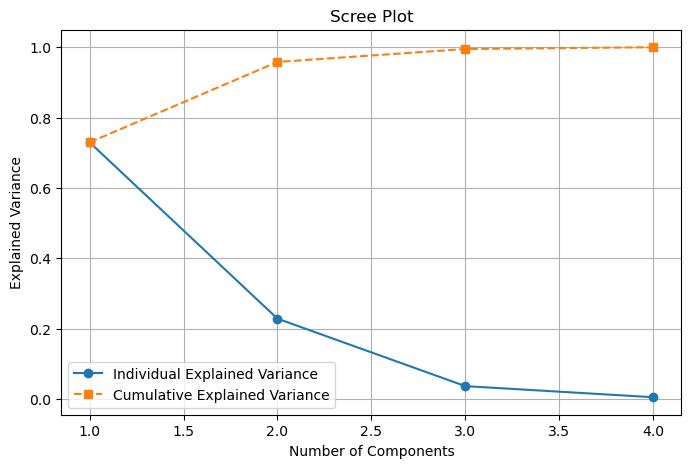

In [13]:
# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Scree Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, 'o-', label='Individual Explained Variance')
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), 's--', label='Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.title('Scree Plot')
plt.grid(True)
plt.legend()
plt.show()

### Choose Number of Components (95% Variance)

In [14]:
pca_95 = PCA(n_components = 0.95)

X_reduced = pca_95.fit_transform(X_scaled)
print(f"Reduced Shape : {X_reduced.shape}")

Reduced Shape : (150, 2)


### Visualize Top 2 Components

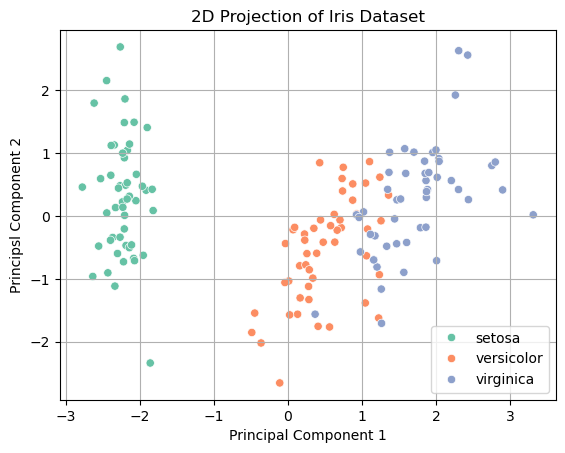

In [20]:
pca_2d = PCA(n_components=2)
X_scaled = pca_2d.fit_transform(X_scaled)

plt.Figure(figsize=(8,6))
sns.scatterplot(x = X_reduced[:,0], y = X_reduced[:,1], hue = iris.target_names[y], palette='Set2')
plt.xlabel("Principal Component 1")
plt.ylabel("Principsl Component 2")
plt.title("2D Projection of Iris Dataset")
plt.grid(True)
plt.show()